In [1]:
try:
    %load_ext autoreload
    %autoreload 2
    %matplotlib widget
    print('Magic loaded')
except:
    print('No magic')

Magic loaded


In [2]:
import sys
sys.path.insert(1,"../")
from pySEA.rayTEM.elements import Lens,Drift,Quadrapole,fix_ray_dims
from pySEA.rayTEM.assemblies import MicroscopeSection
from pySEA.rayTEM.postprocessing import plot2D,plot3D,plotSliceSeries
import numpy as np

In [ ]:
from pySEA.rayTEM.elements import Source
r0=np.asarray( [[1,1,0,0],[1,1,-1,-1]] )
r0=fix_ray_dims(r0,["x","y","xt","yt"])
s = Source(rays=r0)
# s=Source(size=(1,0),np_xy=(3,1),angle=(.5,0),na_xy=(3,1))
s.rays_from_grid()

array([[-0.002, -1.   , -0.002, -1.   ,  0.   ,  1.   ,  0.   ],
       [-0.002, -1.   , -0.002,  0.   ,  0.   ,  1.   ,  0.   ],
       [-0.002, -1.   , -0.002,  1.   ,  0.   ,  1.   ,  0.   ],
       [-0.002,  0.   , -0.002, -1.   ,  0.   ,  1.   ,  0.   ],
       [-0.002,  0.   , -0.002,  0.   ,  0.   ,  1.   ,  0.   ],
       [-0.002,  0.   , -0.002,  1.   ,  0.   ,  1.   ,  0.   ],
       [-0.002,  1.   , -0.002, -1.   ,  0.   ,  1.   ,  0.   ],
       [-0.002,  1.   , -0.002,  0.   ,  0.   ,  1.   ,  0.   ],
       [-0.002,  1.   , -0.002,  1.   ,  0.   ,  1.   ,  0.   ],
       [-0.002, -1.   ,  0.   , -1.   ,  0.   ,  1.   ,  0.   ],
       [-0.002, -1.   ,  0.   ,  0.   ,  0.   ,  1.   ,  0.   ],
       [-0.002, -1.   ,  0.   ,  1.   ,  0.   ,  1.   ,  0.   ],
       [-0.002,  0.   ,  0.   , -1.   ,  0.   ,  1.   ,  0.   ],
       [-0.002,  0.   ,  0.   ,  0.   ,  0.   ,  1.   ,  0.   ],
       [-0.002,  0.   ,  0.   ,  1.   ,  0.   ,  1.   ,  0.   ],
       [-0.002,  1.   ,  

In [4]:
# Construct our microscope section: drifts and lenses
elements=[
    s,
    Drift(length=1),
	Lens(strength=3.5,length=.1), Drift(length=1), 
    Quadrapole(strength=.5,length=.1), Drift(length=1.9),
	Lens(strength=3,length=.1), Drift(length=1),
    Quadrapole(strength=-.2,length=.1), Drift(length=3.9)
    ]

section=MicroscopeSection(elements=elements)
section

TypeError: unhashable type: 'numpy.ndarray'

name     kind     position length   strength calibrat
[[ 1.  0 Source   0        0                 None    
         Drift    0        1                 None    
         QLens    1        0.1      3.5      None    
         Drift    1.1      1                 None    
         Quad     2.1      0.1      0.5      None    
         Drift    2.2      1.9               None    
         QLens    4.1      0.1      3        None    
         Drift    4.2      1                 None    
         Quad     5.2      0.1      -0.2     None    
         Drift    5.3      3.9               None    

In [22]:
section.propagate_ray().shape

(10, 9, 7)

Construct our list of rays: starting positions and angles. A minimum of two (is required for auto-detection of image/diffraction planes (one normal, one at an angle, both from the same point) 

In [9]:
r0=np.asarray( [[1,1,0,0],[1,1,-1,-1]] )
r0=fix_ray_dims(r0,["x","y","xt","yt"])

Propagate and 2D plot

diffraction rays (x2) in X: must be finite x, zero y, zero xt and yt
image rays (x2) in X: must be finite xt, zero yt, zero x and y


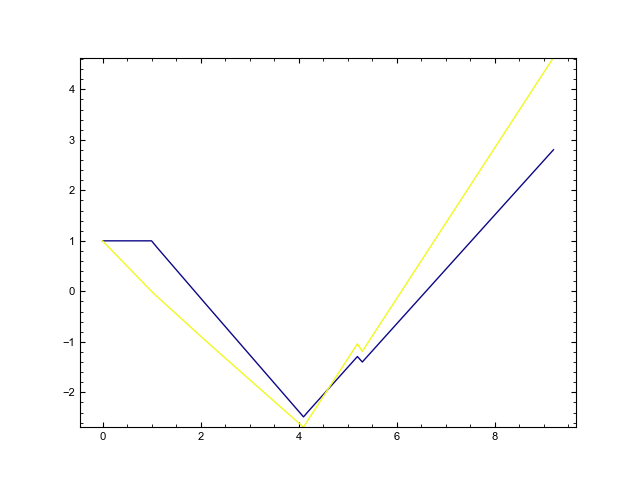

In [11]:
r1=section.propagate_ray(r0)
plot2D(r1)

In [12]:
section

name     kind     position length   strength calibrat
         Drift    0        1                 None    
         QLens    1        0.1      3.5      None    
         Drift    1.1      1                 None    
         Quad     2.1      0.1      0.5      None    
         Drift    2.2      1.9               None    
         QLens    4.1      0.1      3        None    
         Drift    4.2      1                 None    
         Quad     5.2      0.1      -0.2     None    
         Drift    5.3      3.9               None

In [8]:
section.show()

AttributeError: 'Drift' object has no attribute 'rays'

Alternate list of rays: a whole series of positions and angles should make visualizing the image and diffraction planes easier.

In [9]:
r0=[]
for x in np.arange(-2,3):
	for y in np.arange(-2,3):
		for xt in [-1,0,1]:
			for yt in [-1,0,1]:
				r0.append([x,y,xt,yt])
r0=fix_ray_dims(np.asarray(r0),["x","y","xt","yt"])
r0.shape

(225, 7)

Propoagate and 3D plot

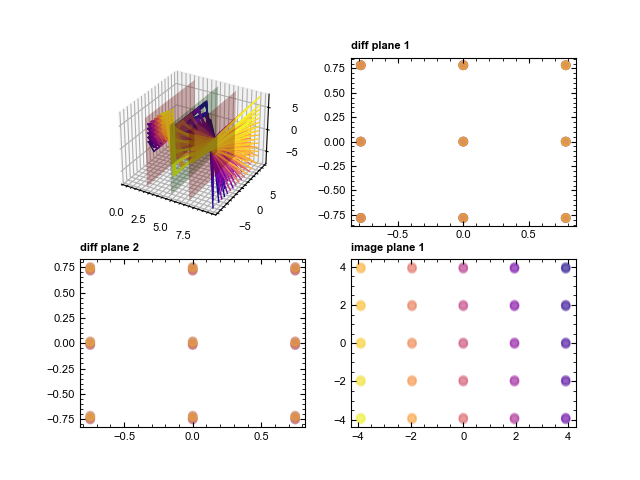

In [10]:
r1=section.propagate_ray(r0)
plot3D(r1)

In [9]:
#plotSliceSeries(r1,20,20)